# E-Commerce Marketplace Analytics
## Python EDA, Forecasting & Predictive Modelling

**Author:** Ayush Dodia | [GitHub](https://github.com/AyushDodia0125) | ayushdodia2001@gmail.com

**Stack:** Python · pandas · matplotlib · seaborn · scikit-learn · statsmodels

**Dataset:** Synthetic Indian e-commerce marketplace (2023–2024)
- 5,000 customers · 500 sellers · 2,000 products
- 50,000 orders · 200,000 clickstream events · ~40,000 inventory records

---

| Section | Analysis |
|---------|----------|
| 1 | Setup & Data Loading |
| 2 | Exploratory Data Analysis |
| 3 | Seasonality & Trend Analysis |
| 4 | Demand Forecasting |
| 5 | Customer Churn Prediction |
| 6 | Price Elasticity Analysis |
| 7 | Key Findings Summary |

## Section 1 — Setup & Data Loading

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from scipy import stats

plt.rcParams.update({
    'figure.dpi': 150, 'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa', 'axes.grid': True,
    'grid.color': 'white', 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'DejaVu Sans', 'axes.titlesize': 13, 'axes.labelsize': 11,
})
PALETTE = ['#1a6faf','#e05c2a','#2eaa72','#d4a017','#8e44ad','#e74c3c','#16a085']
sns.set_palette(PALETTE)
print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
DB_PATH = Path('..') / 'marketplace.db'
conn = sqlite3.connect(DB_PATH)

customers = pd.read_sql('SELECT * FROM customers', conn, parse_dates=['signup_date'])
sellers   = pd.read_sql('SELECT * FROM sellers',   conn, parse_dates=['join_date'])
products  = pd.read_sql('SELECT * FROM products',  conn, parse_dates=['listing_date'])
orders    = pd.read_sql('SELECT * FROM orders',    conn, parse_dates=['order_date'])
events    = pd.read_sql('SELECT * FROM events',    conn, parse_dates=['event_ts'])
inventory = pd.read_sql('SELECT * FROM inventory', conn, parse_dates=['stock_date'])
conn.close()

for name, df in [('customers',customers),('sellers',sellers),('products',products),
                  ('orders',orders),('events',events),('inventory',inventory)]:
    print(f"  {name:<12} {df.shape[0]:>8,} rows  x  {df.shape[1]:>2} cols")

  customers       5,000 rows  x   7 cols
  sellers           500 rows  x   8 cols
  products        2,000 rows  x   7 cols
  orders         50,000 rows  x  10 cols
  events        200,000 rows  x   7 cols
  inventory      39,381 rows  x   7 cols


In [3]:
# Data quality check
print("=== Null values ===")
for name, df in [('orders',orders),('customers',customers),('products',products)]:
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    print(f"{name}: {dict(nulls) if len(nulls) else 'no nulls checkmark'}")

print("\n=== Order status split ===")
print(orders['status'].value_counts(normalize=True).mul(100).round(2).to_string())

=== Null values ===
orders: {'delivery_days': np.int64(10987)}
customers: no nulls checkmark
products: no nulls checkmark

=== Order status split ===
status
Delivered     78.03
Cancelled     10.02
Returned       7.99
Processing     3.96


---
## Section 2 — Exploratory Data Analysis

### 2.1 — GMV Distribution

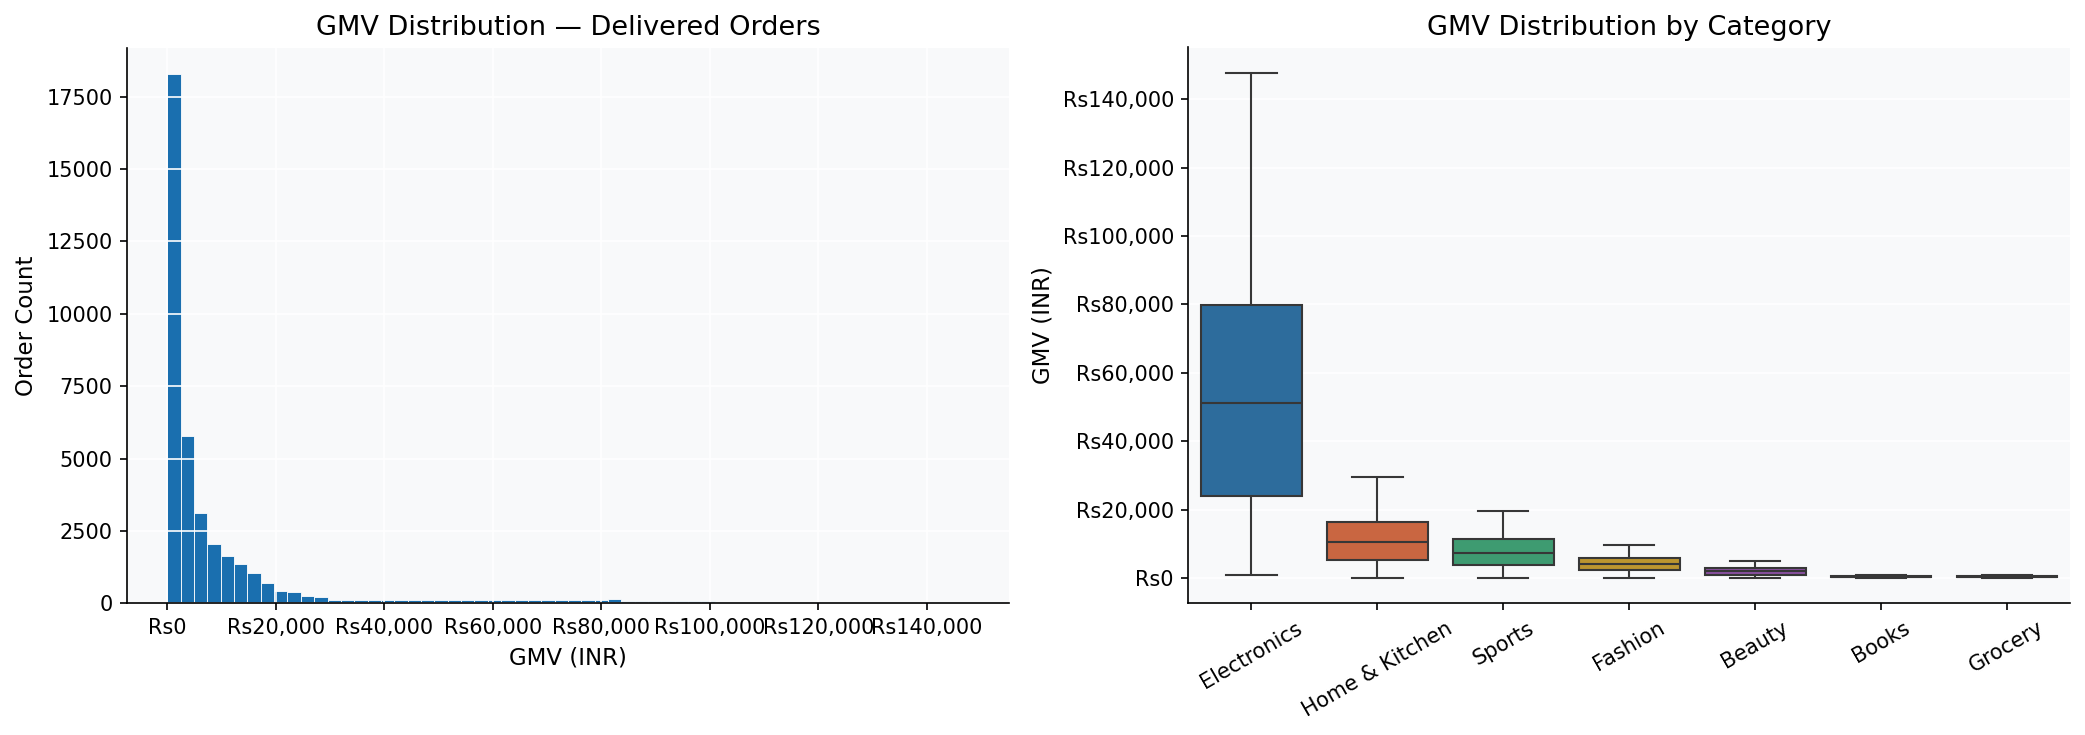

Median GMV : Rs2,845
Mean GMV   : Rs11,155
Skewness   : 3.14


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
delivered = orders[orders['status'] == 'Delivered']['gmv']

axes[0].hist(delivered, bins=60, color=PALETTE[0], edgecolor='white', linewidth=0.4)
axes[0].set_title('GMV Distribution — Delivered Orders')
axes[0].set_xlabel('GMV (INR)')
axes[0].set_ylabel('Order Count')
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'Rs{x:,.0f}'))

cat_gmv = orders[orders['status']=='Delivered'].merge(
    products[['product_id','category']], on='product_id')
order_cats = cat_gmv.groupby('category')['gmv'].median().sort_values(ascending=False).index
sns.boxplot(data=cat_gmv, x='category', y='gmv', order=order_cats,
            palette=PALETTE, ax=axes[1], flierprops=dict(markersize=2, alpha=0.3))
axes[1].set_title('GMV Distribution by Category')
axes[1].set_xlabel('')
axes[1].set_ylabel('GMV (INR)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'Rs{x:,.0f}'))

plt.tight_layout()
plt.savefig('../dashboard/screenshots/01_gmv_distribution.png', bbox_inches='tight')
plt.show()

print(f"Median GMV : Rs{delivered.median():,.0f}")
print(f"Mean GMV   : Rs{delivered.mean():,.0f}")
print(f"Skewness   : {delivered.skew():.2f}")

### 2.2 — Category Performance

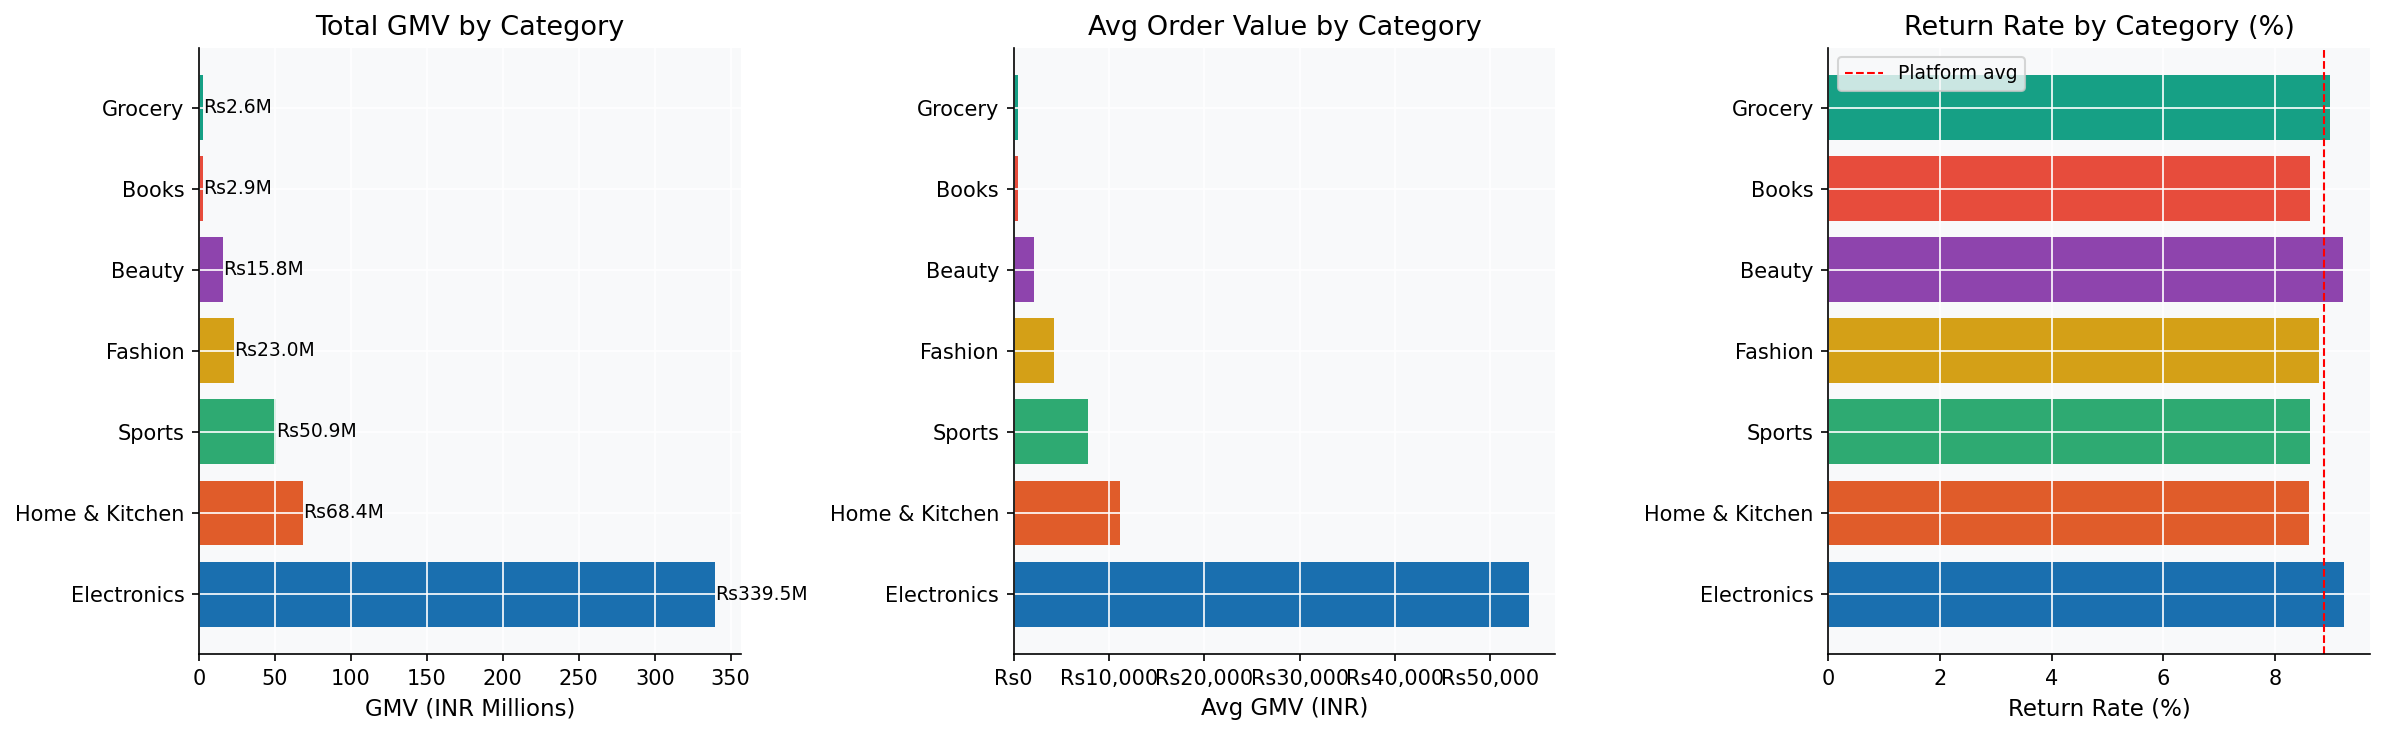

In [5]:
cat_perf = (
    orders[orders['status'] != 'Cancelled']
    .merge(products[['product_id','category']], on='product_id')
    .groupby('category')
    .agg(total_orders=('order_id','count'), total_gmv=('gmv','sum'),
         avg_gmv=('gmv','mean'), return_rate=('return_flag','mean'),
         avg_discount=('discount_amt','mean'))
    .reset_index()
    .sort_values('total_gmv', ascending=False)
)
cat_perf['return_rate_pct'] = cat_perf['return_rate'] * 100

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

bars = axes[0].barh(cat_perf['category'], cat_perf['total_gmv']/1e6,
                    color=PALETTE[:len(cat_perf)])
axes[0].set_title('Total GMV by Category')
axes[0].set_xlabel('GMV (INR Millions)')
for bar, val in zip(bars, cat_perf['total_gmv']/1e6):
    axes[0].text(val+0.1, bar.get_y()+bar.get_height()/2,
                 f'Rs{val:.1f}M', va='center', fontsize=9)

axes[1].barh(cat_perf['category'], cat_perf['avg_gmv'], color=PALETTE[:len(cat_perf)])
axes[1].set_title('Avg Order Value by Category')
axes[1].set_xlabel('Avg GMV (INR)')
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'Rs{x:,.0f}'))

axes[2].barh(cat_perf['category'], cat_perf['return_rate_pct'], color=PALETTE[:len(cat_perf)])
axes[2].set_title('Return Rate by Category (%)')
axes[2].set_xlabel('Return Rate (%)')
axes[2].axvline(cat_perf['return_rate_pct'].mean(), color='red',
                linestyle='--', linewidth=1, label='Platform avg')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('../dashboard/screenshots/02_category_performance.png', bbox_inches='tight')
plt.show()

### 2.3 — Customer Segment & Acquisition Channel

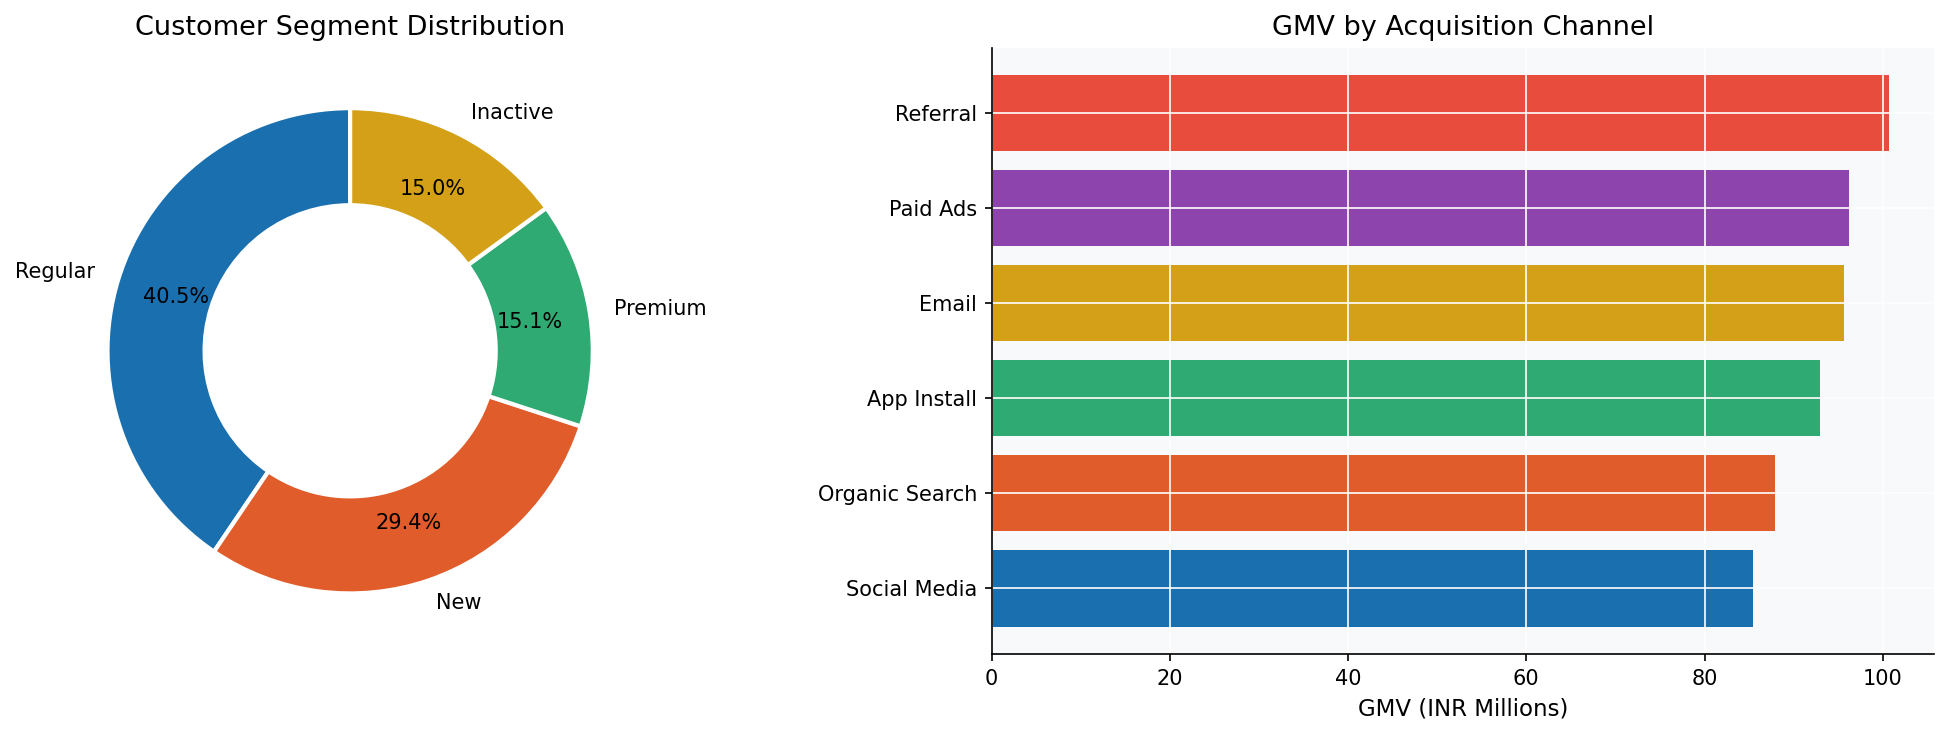

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

seg_counts = customers['segment'].value_counts()
wedge_props = dict(width=0.4, edgecolor='white', linewidth=2)
axes[0].pie(seg_counts.values, labels=seg_counts.index,
            colors=PALETTE[:len(seg_counts)], autopct='%1.1f%%',
            pctdistance=0.75, wedgeprops=wedge_props, startangle=90)
axes[0].set_title('Customer Segment Distribution')

channel_orders = (
    orders.merge(customers[['customer_id','acquisition_channel']], on='customer_id')
    .groupby('acquisition_channel')
    .agg(orders=('order_id','count'), gmv=('gmv','sum'))
    .sort_values('gmv', ascending=True)
)
axes[1].barh(channel_orders.index, channel_orders['gmv']/1e6,
             color=PALETTE[:len(channel_orders)])
axes[1].set_title('GMV by Acquisition Channel')
axes[1].set_xlabel('GMV (INR Millions)')

plt.tight_layout()
plt.savefig('../dashboard/screenshots/03_customer_segments.png', bbox_inches='tight')
plt.show()

### 2.4 — Correlation Heatmap

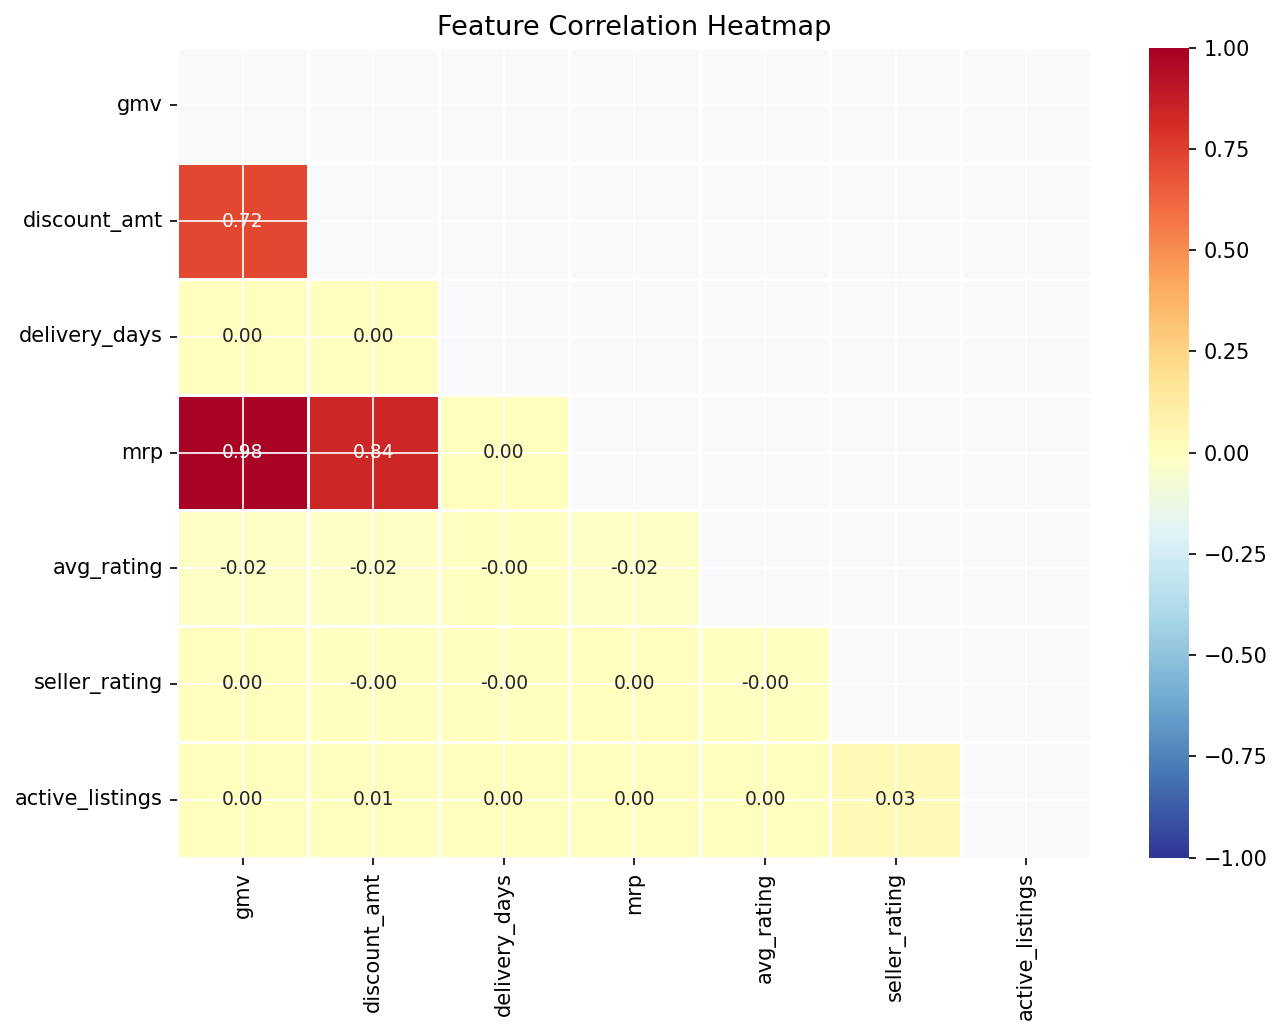

MRP vs GMV correlation       : 0.982
Discount vs GMV correlation  : 0.721
Seller rating vs Delivery    : -0.001


In [7]:
order_features = (
    orders[orders['status'] != 'Cancelled']
    .merge(products[['product_id','category','avg_rating','mrp']], on='product_id')
    .merge(sellers[['seller_id','seller_rating','active_listings']], on='seller_id')
)
numeric_cols = ['gmv','discount_amt','delivery_days','mrp',
                'avg_rating','seller_rating','active_listings']
corr = order_features[numeric_cols].dropna().corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, ax=ax, linewidths=0.5, annot_kws={'size':9}, vmin=-1, vmax=1)
ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('../dashboard/screenshots/04_correlation_heatmap.png', bbox_inches='tight')
plt.show()

print(f"MRP vs GMV correlation       : {corr.loc['mrp','gmv']:.3f}")
print(f"Discount vs GMV correlation  : {corr.loc['discount_amt','gmv']:.3f}")
print(f"Seller rating vs Delivery    : {corr.loc['seller_rating','delivery_days']:.3f}")

---
## Section 3 — Seasonality & Trend Analysis

### 3.1 — Monthly GMV Trend with MoM Growth

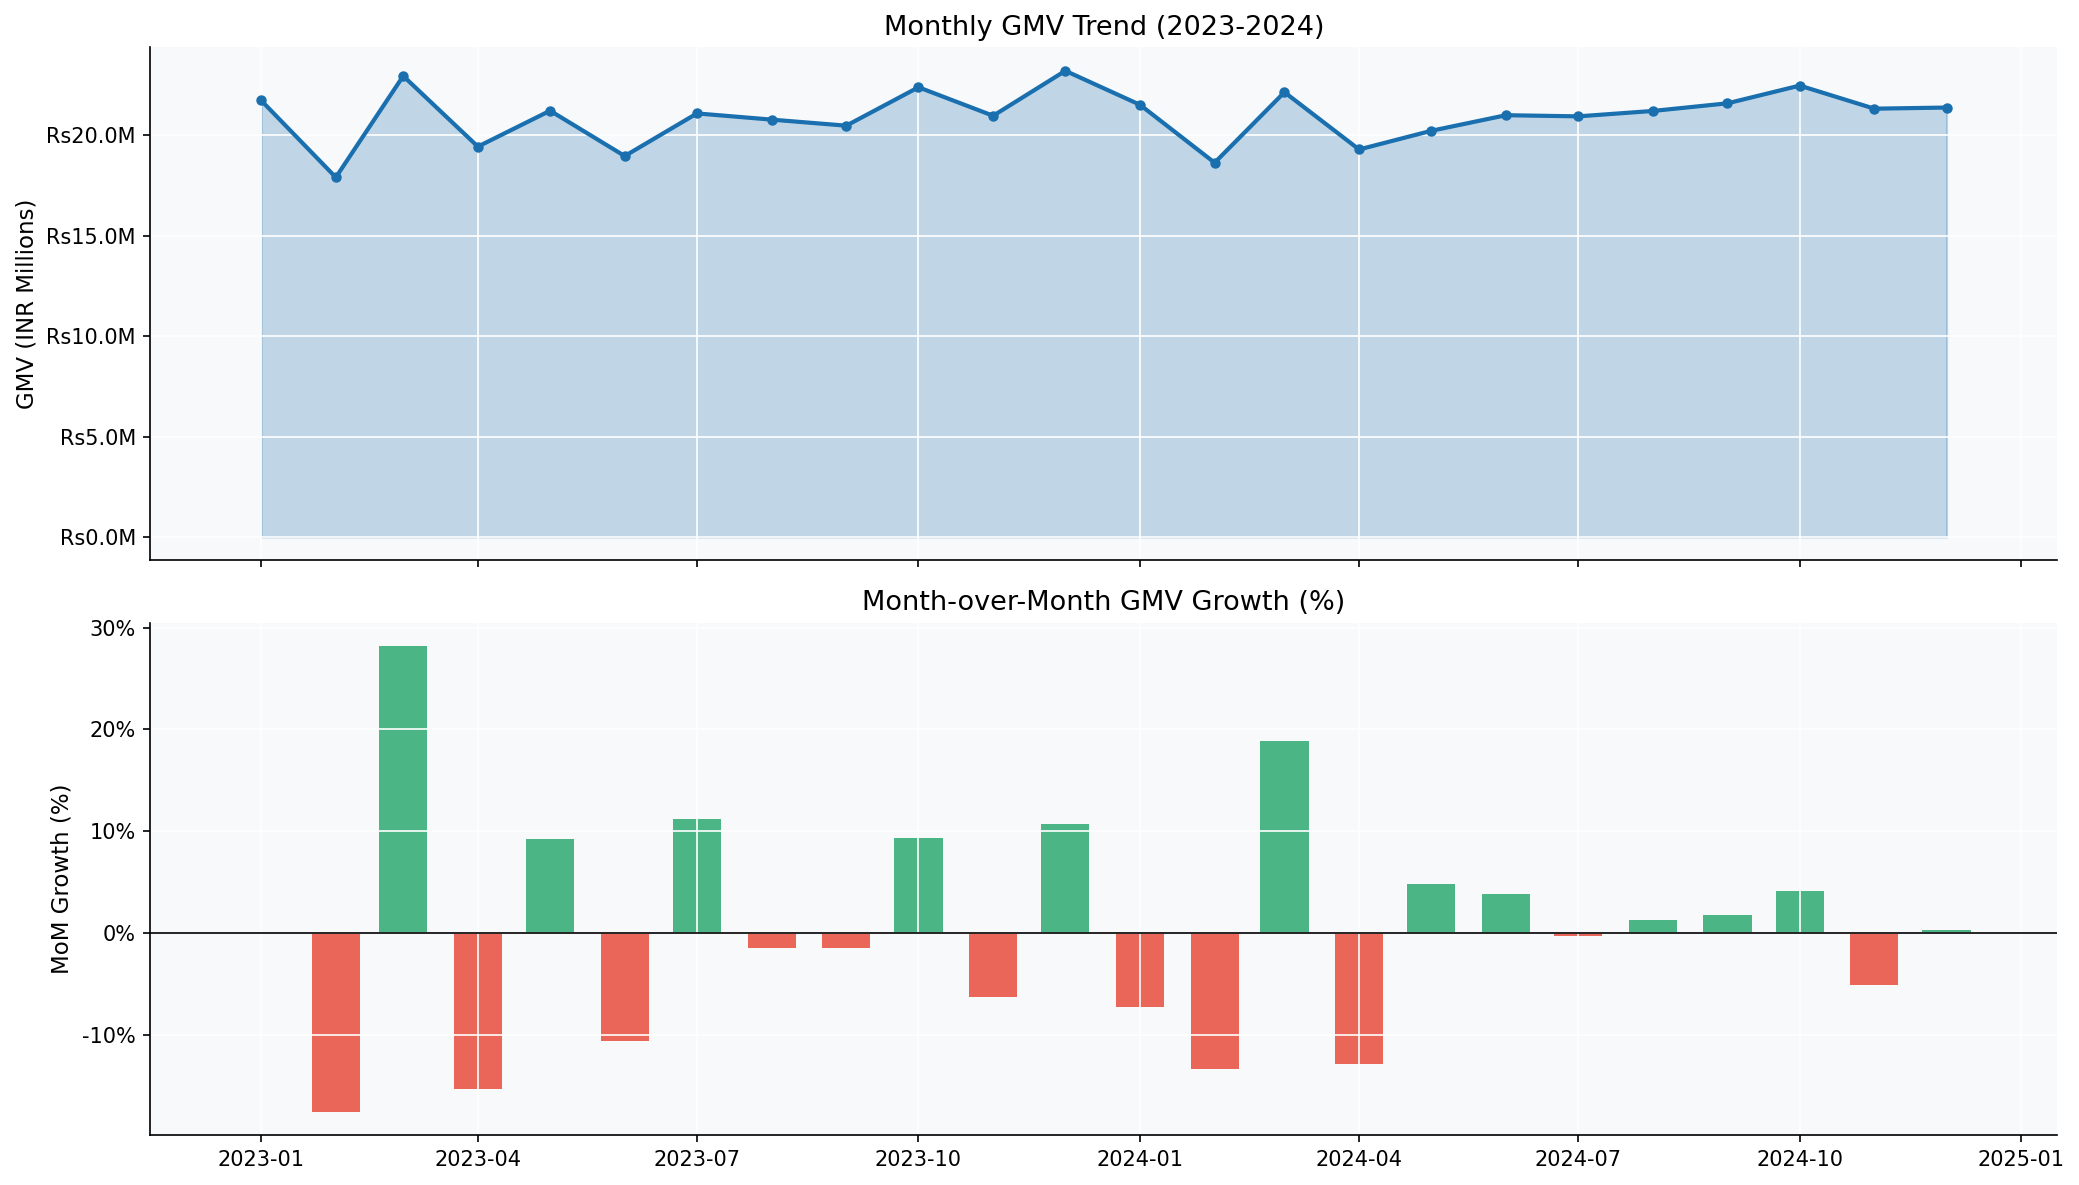

Peak GMV month : 2023-12
Peak GMV value : Rs23.22M
Avg MoM growth : 0.5%


In [8]:
monthly = (
    orders[orders['status'] != 'Cancelled']
    .assign(month=lambda d: d['order_date'].dt.to_period('M'))
    .groupby('month')
    .agg(gmv=('gmv','sum'), orders=('order_id','count'))
    .reset_index()
)
monthly['month_dt']  = monthly['month'].dt.to_timestamp()
monthly['mom_growth'] = monthly['gmv'].pct_change() * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].fill_between(monthly['month_dt'], monthly['gmv']/1e6, alpha=0.25, color=PALETTE[0])
axes[0].plot(monthly['month_dt'], monthly['gmv']/1e6, color=PALETTE[0],
             linewidth=2, marker='o', markersize=4)
axes[0].set_title('Monthly GMV Trend (2023-2024)')
axes[0].set_ylabel('GMV (INR Millions)')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'Rs{x:.1f}M'))

colors_bar = [PALETTE[2] if v >= 0 else PALETTE[5] for v in monthly['mom_growth'].fillna(0)]
axes[1].bar(monthly['month_dt'], monthly['mom_growth'].fillna(0),
            color=colors_bar, width=20, alpha=0.85)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Month-over-Month GMV Growth (%)')
axes[1].set_ylabel('MoM Growth (%)')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'{x:.0f}%'))

plt.tight_layout()
plt.savefig('../dashboard/screenshots/05_monthly_gmv_trend.png', bbox_inches='tight')
plt.show()

print(f"Peak GMV month : {monthly.loc[monthly['gmv'].idxmax(),'month']}")
print(f"Peak GMV value : Rs{monthly['gmv'].max()/1e6:.2f}M")
print(f"Avg MoM growth : {monthly['mom_growth'].mean():.1f}%")

### 3.2 — Day-of-Week & Hour-of-Day Purchase Heatmap

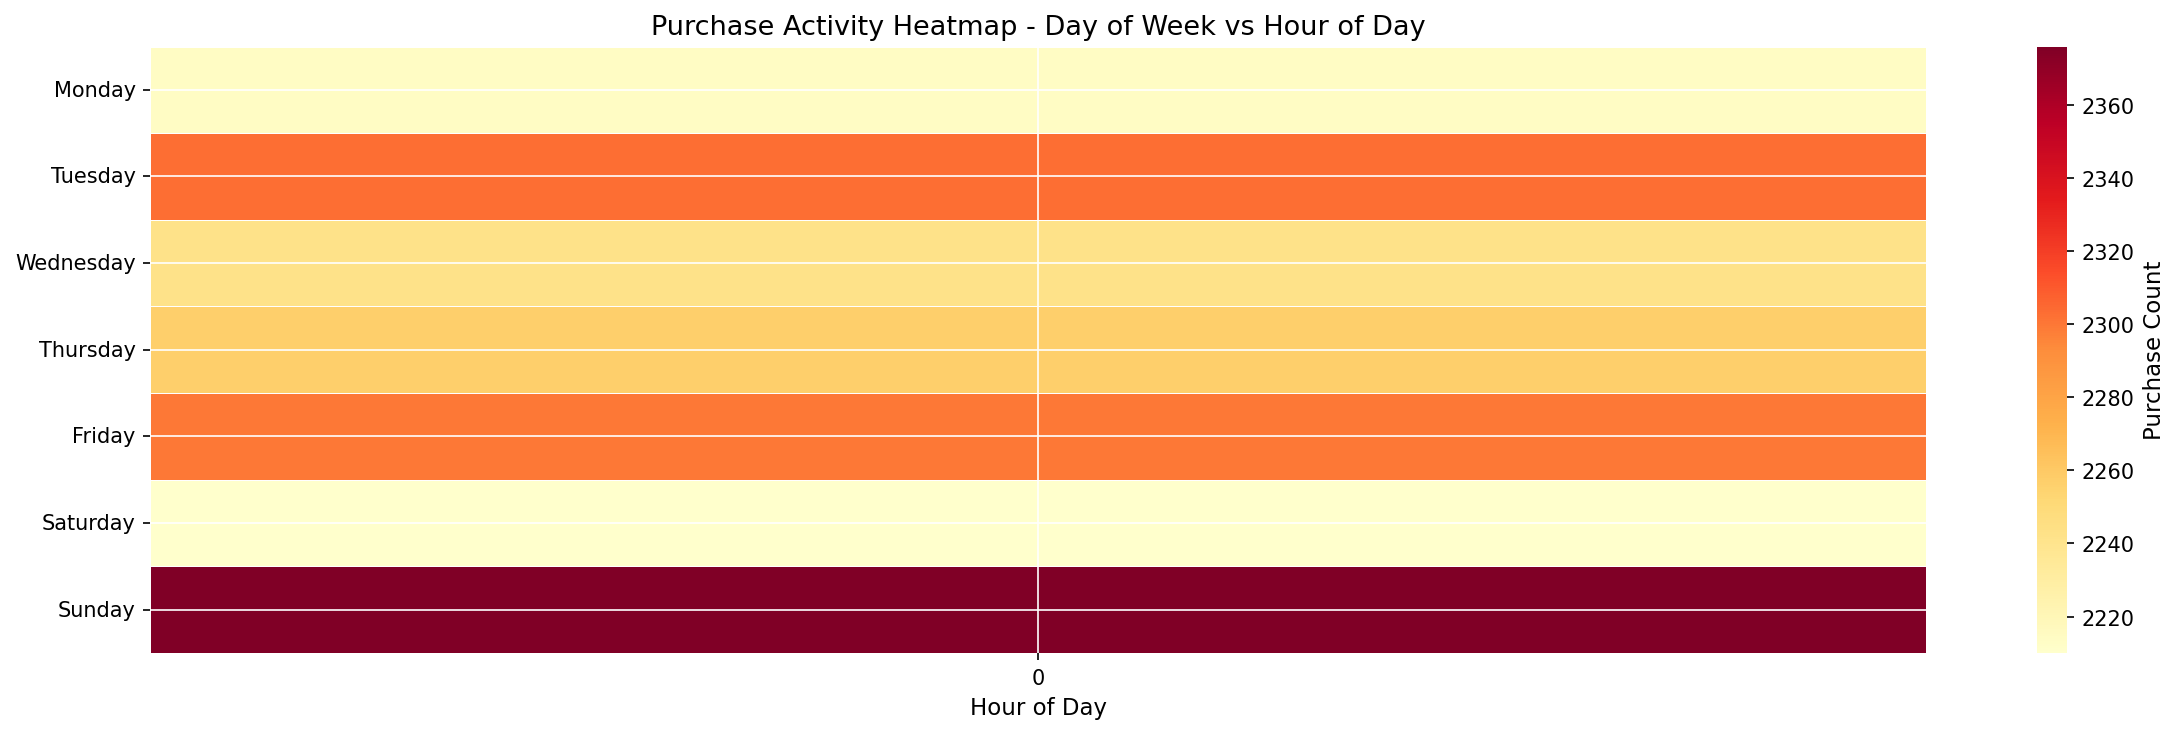

In [9]:
events['hour']    = events['event_ts'].dt.hour
events['weekday'] = events['event_ts'].dt.day_name()

purchase_events = events[events['event_type'] == 'purchase'].copy()
pivot = (purchase_events
         .groupby(['weekday','hour'])
         .size()
         .unstack(fill_value=0))

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
pivot = pivot.reindex([d for d in day_order if d in pivot.index])

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(pivot, cmap='YlOrRd', ax=ax, linewidths=0.3,
            cbar_kws={'label': 'Purchase Count'})
ax.set_title('Purchase Activity Heatmap - Day of Week vs Hour of Day')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('../dashboard/screenshots/06_activity_heatmap.png', bbox_inches='tight')
plt.show()

### 3.3 — Discount Burn Rate Analysis

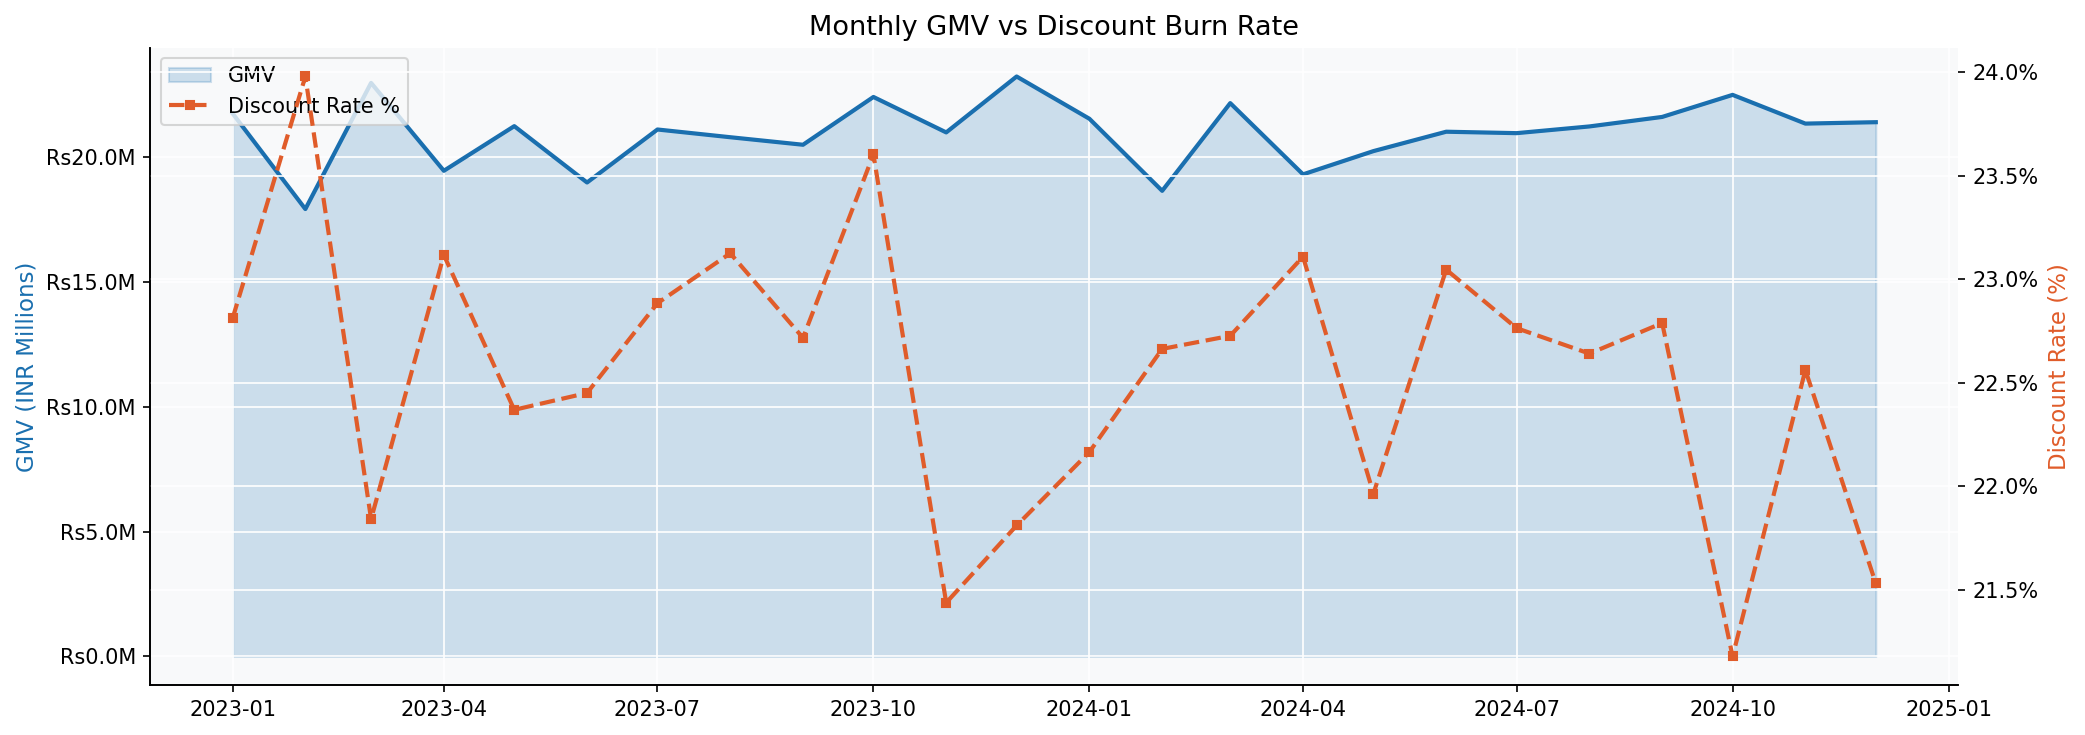

Avg monthly discount rate: 22.6%


In [10]:
disc_monthly = (
    orders[orders['status'] != 'Cancelled']
    .assign(month=lambda d: d['order_date'].dt.to_period('M'))
    .groupby('month')
    .agg(gmv=('gmv','sum'), discount=('discount_amt','sum'))
    .reset_index()
)
disc_monthly['month_dt']      = disc_monthly['month'].dt.to_timestamp()
disc_monthly['gross_rev']     = disc_monthly['gmv'] + disc_monthly['discount']
disc_monthly['discount_rate'] = disc_monthly['discount'] / disc_monthly['gross_rev'] * 100

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.fill_between(disc_monthly['month_dt'], disc_monthly['gmv']/1e6,
                 alpha=0.2, color=PALETTE[0], label='GMV')
ax1.plot(disc_monthly['month_dt'], disc_monthly['gmv']/1e6, color=PALETTE[0], linewidth=2)
ax1.set_ylabel('GMV (INR Millions)', color=PALETTE[0])
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'Rs{x:.1f}M'))

ax2.plot(disc_monthly['month_dt'], disc_monthly['discount_rate'], color=PALETTE[1],
         linewidth=2, linestyle='--', marker='s', markersize=4, label='Discount Rate %')
ax2.set_ylabel('Discount Rate (%)', color=PALETTE[1])
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'{x:.1f}%'))

ax1.set_title('Monthly GMV vs Discount Burn Rate')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper left')

plt.tight_layout()
plt.savefig('../dashboard/screenshots/07_discount_burn.png', bbox_inches='tight')
plt.show()
print(f"Avg monthly discount rate: {disc_monthly['discount_rate'].mean():.1f}%")

---
## Section 4 — Demand Forecasting

We use **Exponential Smoothing (ETS)** to forecast weekly order volume for the top 3 categories. Training on 80% of the time series, forecasting the remaining 20%.

Forecasting for: ['Beauty', 'Books', 'Sports']


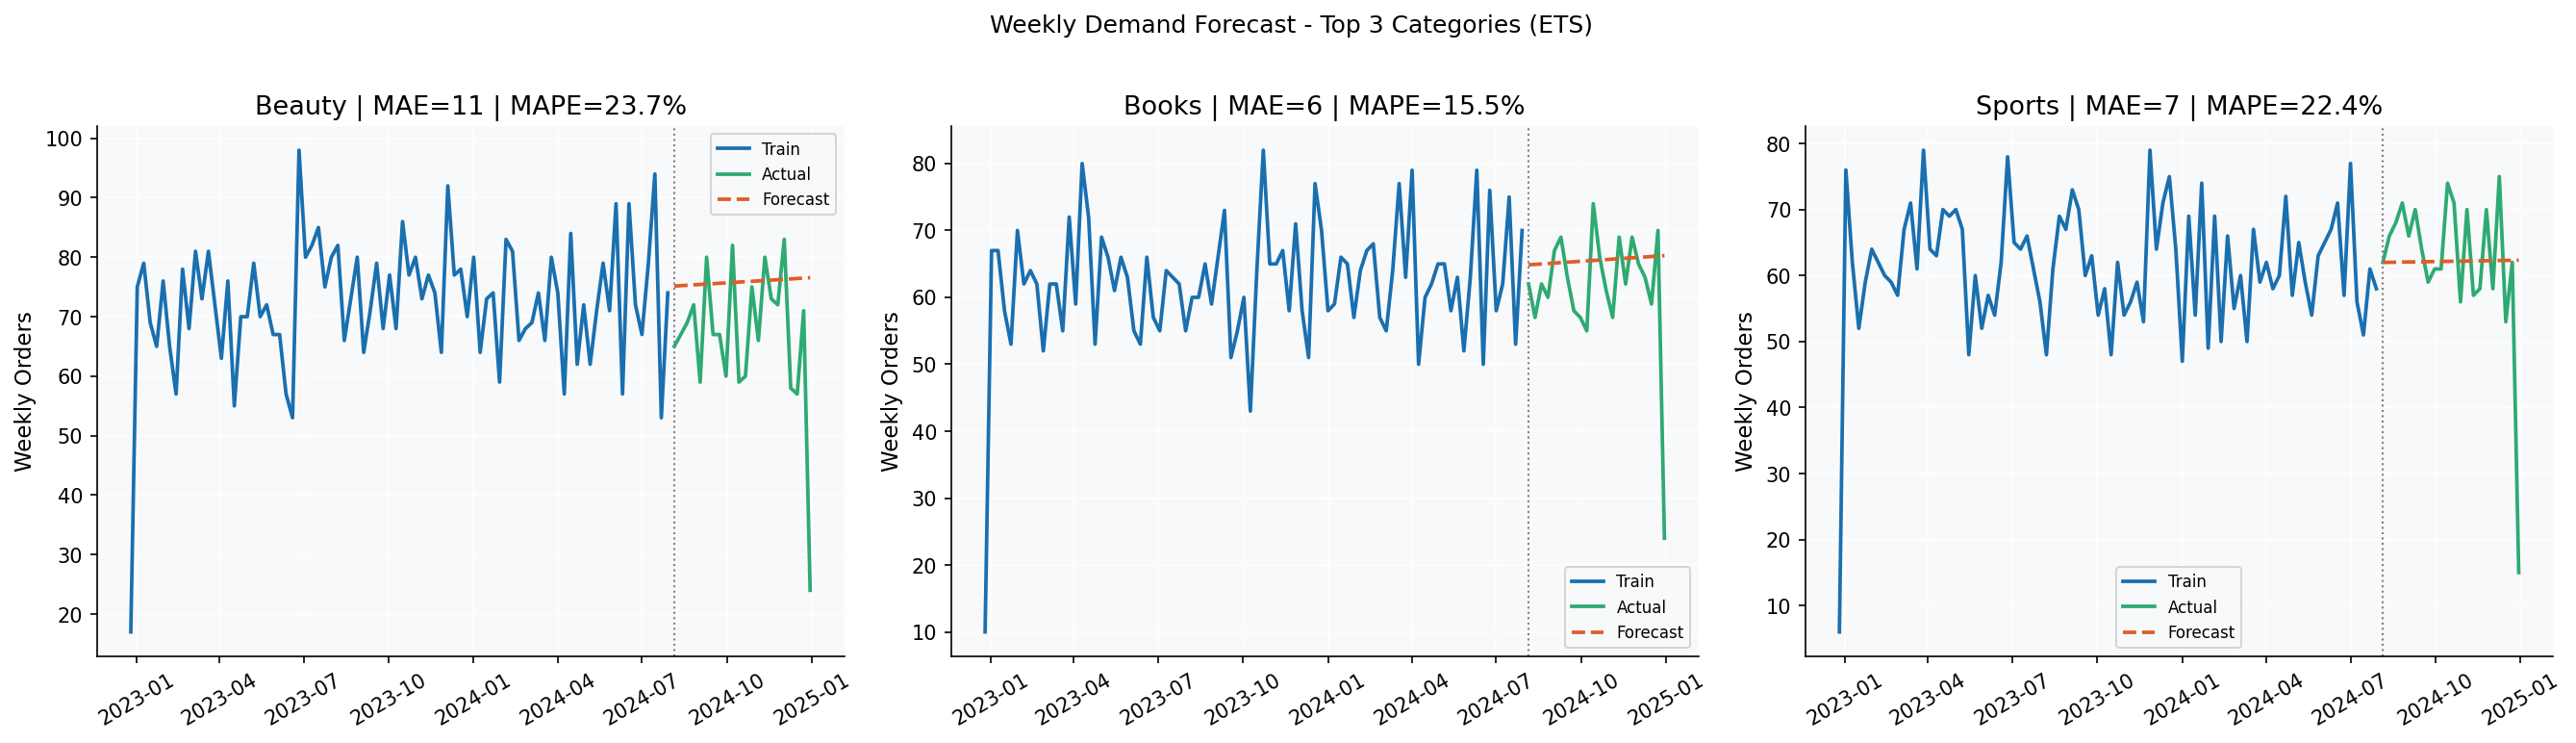

In [11]:
top_cats = (
    orders[orders['status'] != 'Cancelled']
    .merge(products[['product_id','category']], on='product_id')
    .groupby('category')['order_id'].count()
    .nlargest(3).index.tolist()
)
print("Forecasting for:", top_cats)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, cat in enumerate(top_cats):
    cat_orders = (
        orders[orders['status'] != 'Cancelled']
        .merge(products[['product_id','category']], on='product_id')
        .query('category == @cat')
        .assign(week=lambda d: d['order_date'].dt.to_period('W'))
        .groupby('week')['order_id'].count()
        .reset_index()
        .sort_values('week')
        .reset_index(drop=True)
    )
    cat_orders.columns = ['week','order_count']

    split  = int(len(cat_orders) * 0.80)
    train  = cat_orders['order_count'].iloc[:split]
    test   = cat_orders['order_count'].iloc[split:]
    weeks  = cat_orders['week'].dt.to_timestamp()

    model   = ExponentialSmoothing(train, trend='add', seasonal=None,
                                    initialization_method='estimated')
    fitted  = model.fit(optimized=True)
    fc      = fitted.forecast(len(test))

    mae  = np.mean(np.abs(fc.values - test.values))
    mape = np.mean(np.abs((fc.values - test.values) / (test.values + 1e-9))) * 100

    ax = axes[idx]
    ax.plot(weeks.iloc[:split], train.values, color=PALETTE[0], linewidth=1.8, label='Train')
    ax.plot(weeks.iloc[split:], test.values,  color=PALETTE[2], linewidth=1.8, label='Actual')
    ax.plot(weeks.iloc[split:], fc.values,    color=PALETTE[1], linewidth=1.8,
            linestyle='--', label='Forecast')
    ax.axvline(weeks.iloc[split], color='gray', linestyle=':', linewidth=1)
    ax.set_title(f'{cat} | MAE={mae:.0f} | MAPE={mape:.1f}%')
    ax.set_ylabel('Weekly Orders')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Weekly Demand Forecast - Top 3 Categories (ETS)', y=1.02)
plt.tight_layout()
plt.savefig('../dashboard/screenshots/08_demand_forecast.png', bbox_inches='tight')
plt.show()

---
## Section 5 — Customer Churn Prediction

**Churn definition:** Customer has not placed an order in the last 90 days of the dataset period.

In [12]:
ref_date = orders['order_date'].max()
cutoff   = ref_date - pd.Timedelta(days=90)

cust_features = (
    orders[orders['status'] != 'Cancelled']
    .groupby('customer_id')
    .agg(
        last_order_date=('order_date','max'),
        total_orders=('order_id','count'),
        total_gmv=('gmv','sum'),
        avg_gmv=('gmv','mean'),
        avg_discount=('discount_amt','mean'),
        return_count=('return_flag','sum'),
        avg_delivery=('delivery_days','mean'),
    )
    .reset_index()
)
cust_features['days_since_last_order'] = (ref_date - cust_features['last_order_date']).dt.days
cust_features['return_rate']           = cust_features['return_count'] / cust_features['total_orders']
cust_features['avg_delivery']          = cust_features['avg_delivery'].fillna(7)
cust_features['churned']               = (cust_features['last_order_date'] < cutoff).astype(int)
cust_features = cust_features.merge(
    customers[['customer_id','segment','acquisition_channel']], on='customer_id')

print(f"Total customers : {len(cust_features):,}")
print(f"Churned         : {cust_features['churned'].sum():,}  ({cust_features['churned'].mean()*100:.1f}%)")
print(f"Active          : {(~cust_features['churned'].astype(bool)).sum():,}  ({(1-cust_features['churned'].mean())*100:.1f}%)")

Total customers : 5,000
Churned         : 1,597  (31.9%)
Active          : 3,403  (68.1%)


In [13]:
feature_df = pd.get_dummies(
    cust_features[['total_orders','total_gmv','avg_gmv','avg_discount',
                   'return_rate','avg_delivery','days_since_last_order',
                   'segment','acquisition_channel']],
    columns=['segment','acquisition_channel'], drop_first=True
).fillna(0)

X = feature_df.values
y = cust_features['churned'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

model_lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model_lr.fit(X_train, y_train)

y_pred = model_lr.predict(X_test)
y_prob = model_lr.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred, target_names=['Active','Churned']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

              precision    recall  f1-score   support

      Active       1.00      0.98      0.99       681
     Churned       0.96      1.00      0.98       319

    accuracy                           0.98      1000
   macro avg       0.98      0.99      0.98      1000
weighted avg       0.99      0.98      0.99      1000

ROC-AUC Score: 0.9999


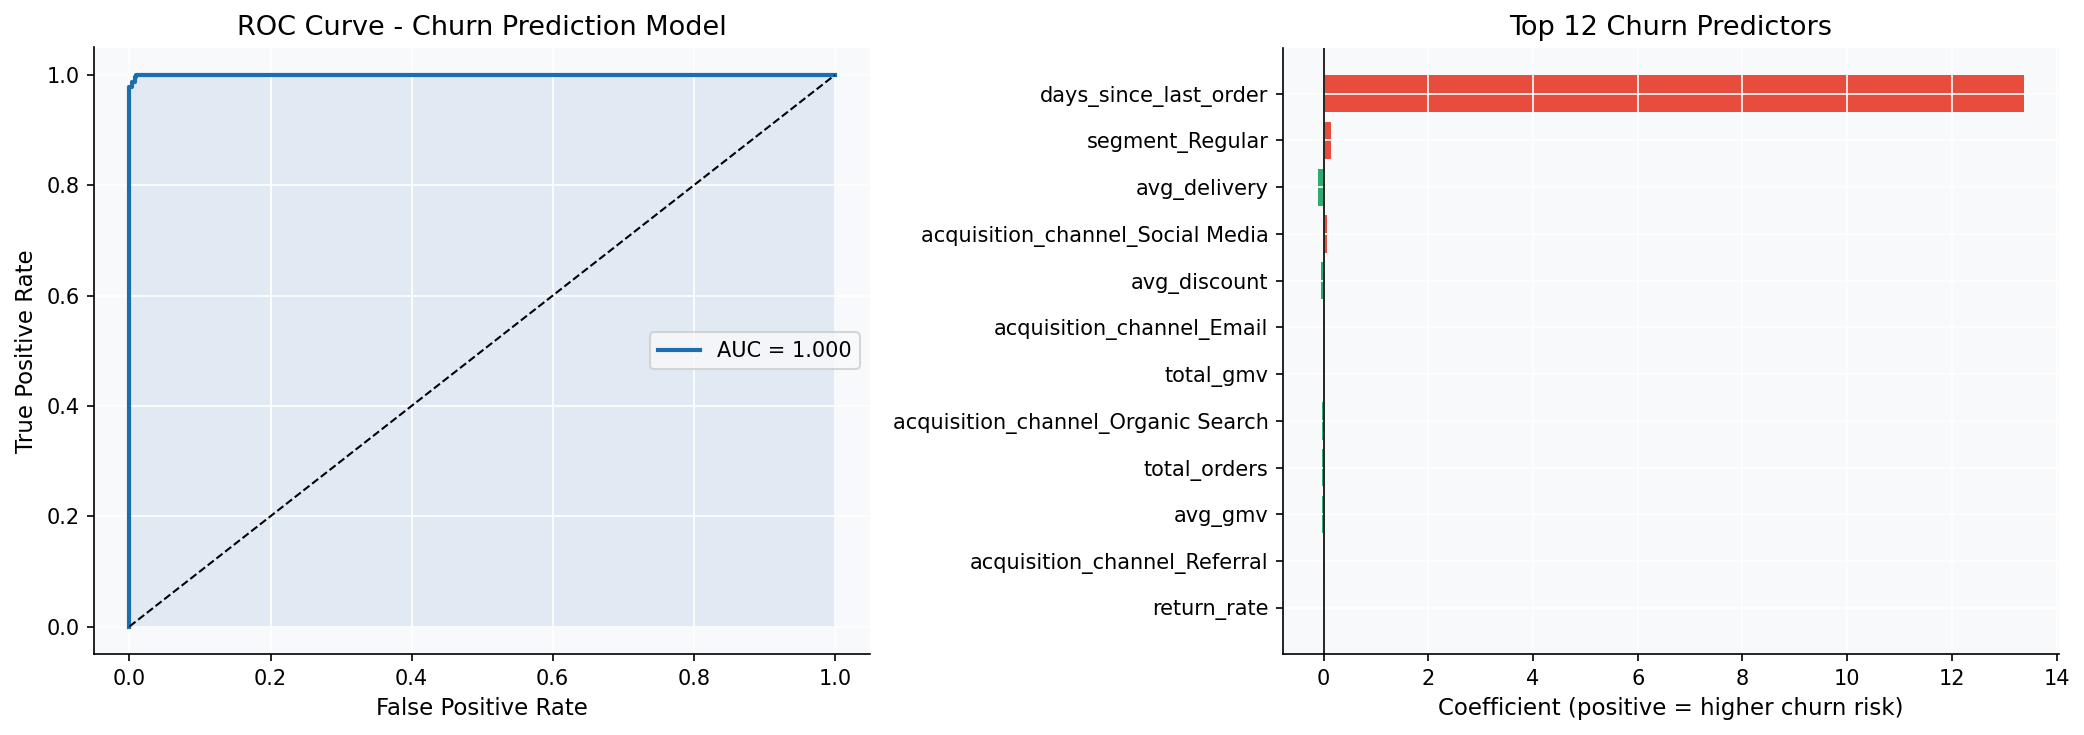

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
axes[0].plot(fpr, tpr, color=PALETTE[0], linewidth=2, label=f'AUC = {auc:.3f}')
axes[0].plot([0,1],[0,1],'k--',linewidth=1)
axes[0].fill_between(fpr, tpr, alpha=0.1, color=PALETTE[0])
axes[0].set_title('ROC Curve - Churn Prediction Model')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

feat_names = feature_df.columns.tolist()
coef_df = (pd.DataFrame({'feature':feat_names,'coefficient':model_lr.coef_[0]})
           .assign(abs_coef=lambda d: d['coefficient'].abs())
           .sort_values('abs_coef', ascending=True)
           .tail(12))
colors_coef = [PALETTE[5] if c > 0 else PALETTE[2] for c in coef_df['coefficient']]
axes[1].barh(coef_df['feature'], coef_df['coefficient'], color=colors_coef)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Top 12 Churn Predictors')
axes[1].set_xlabel('Coefficient (positive = higher churn risk)')

plt.tight_layout()
plt.savefig('../dashboard/screenshots/09_churn_model.png', bbox_inches='tight')
plt.show()

---
## Section 6 — Price Elasticity Analysis

Measures how discount depth (%) affects units sold per category. Slope = additional units sold per 1% increase in discount.

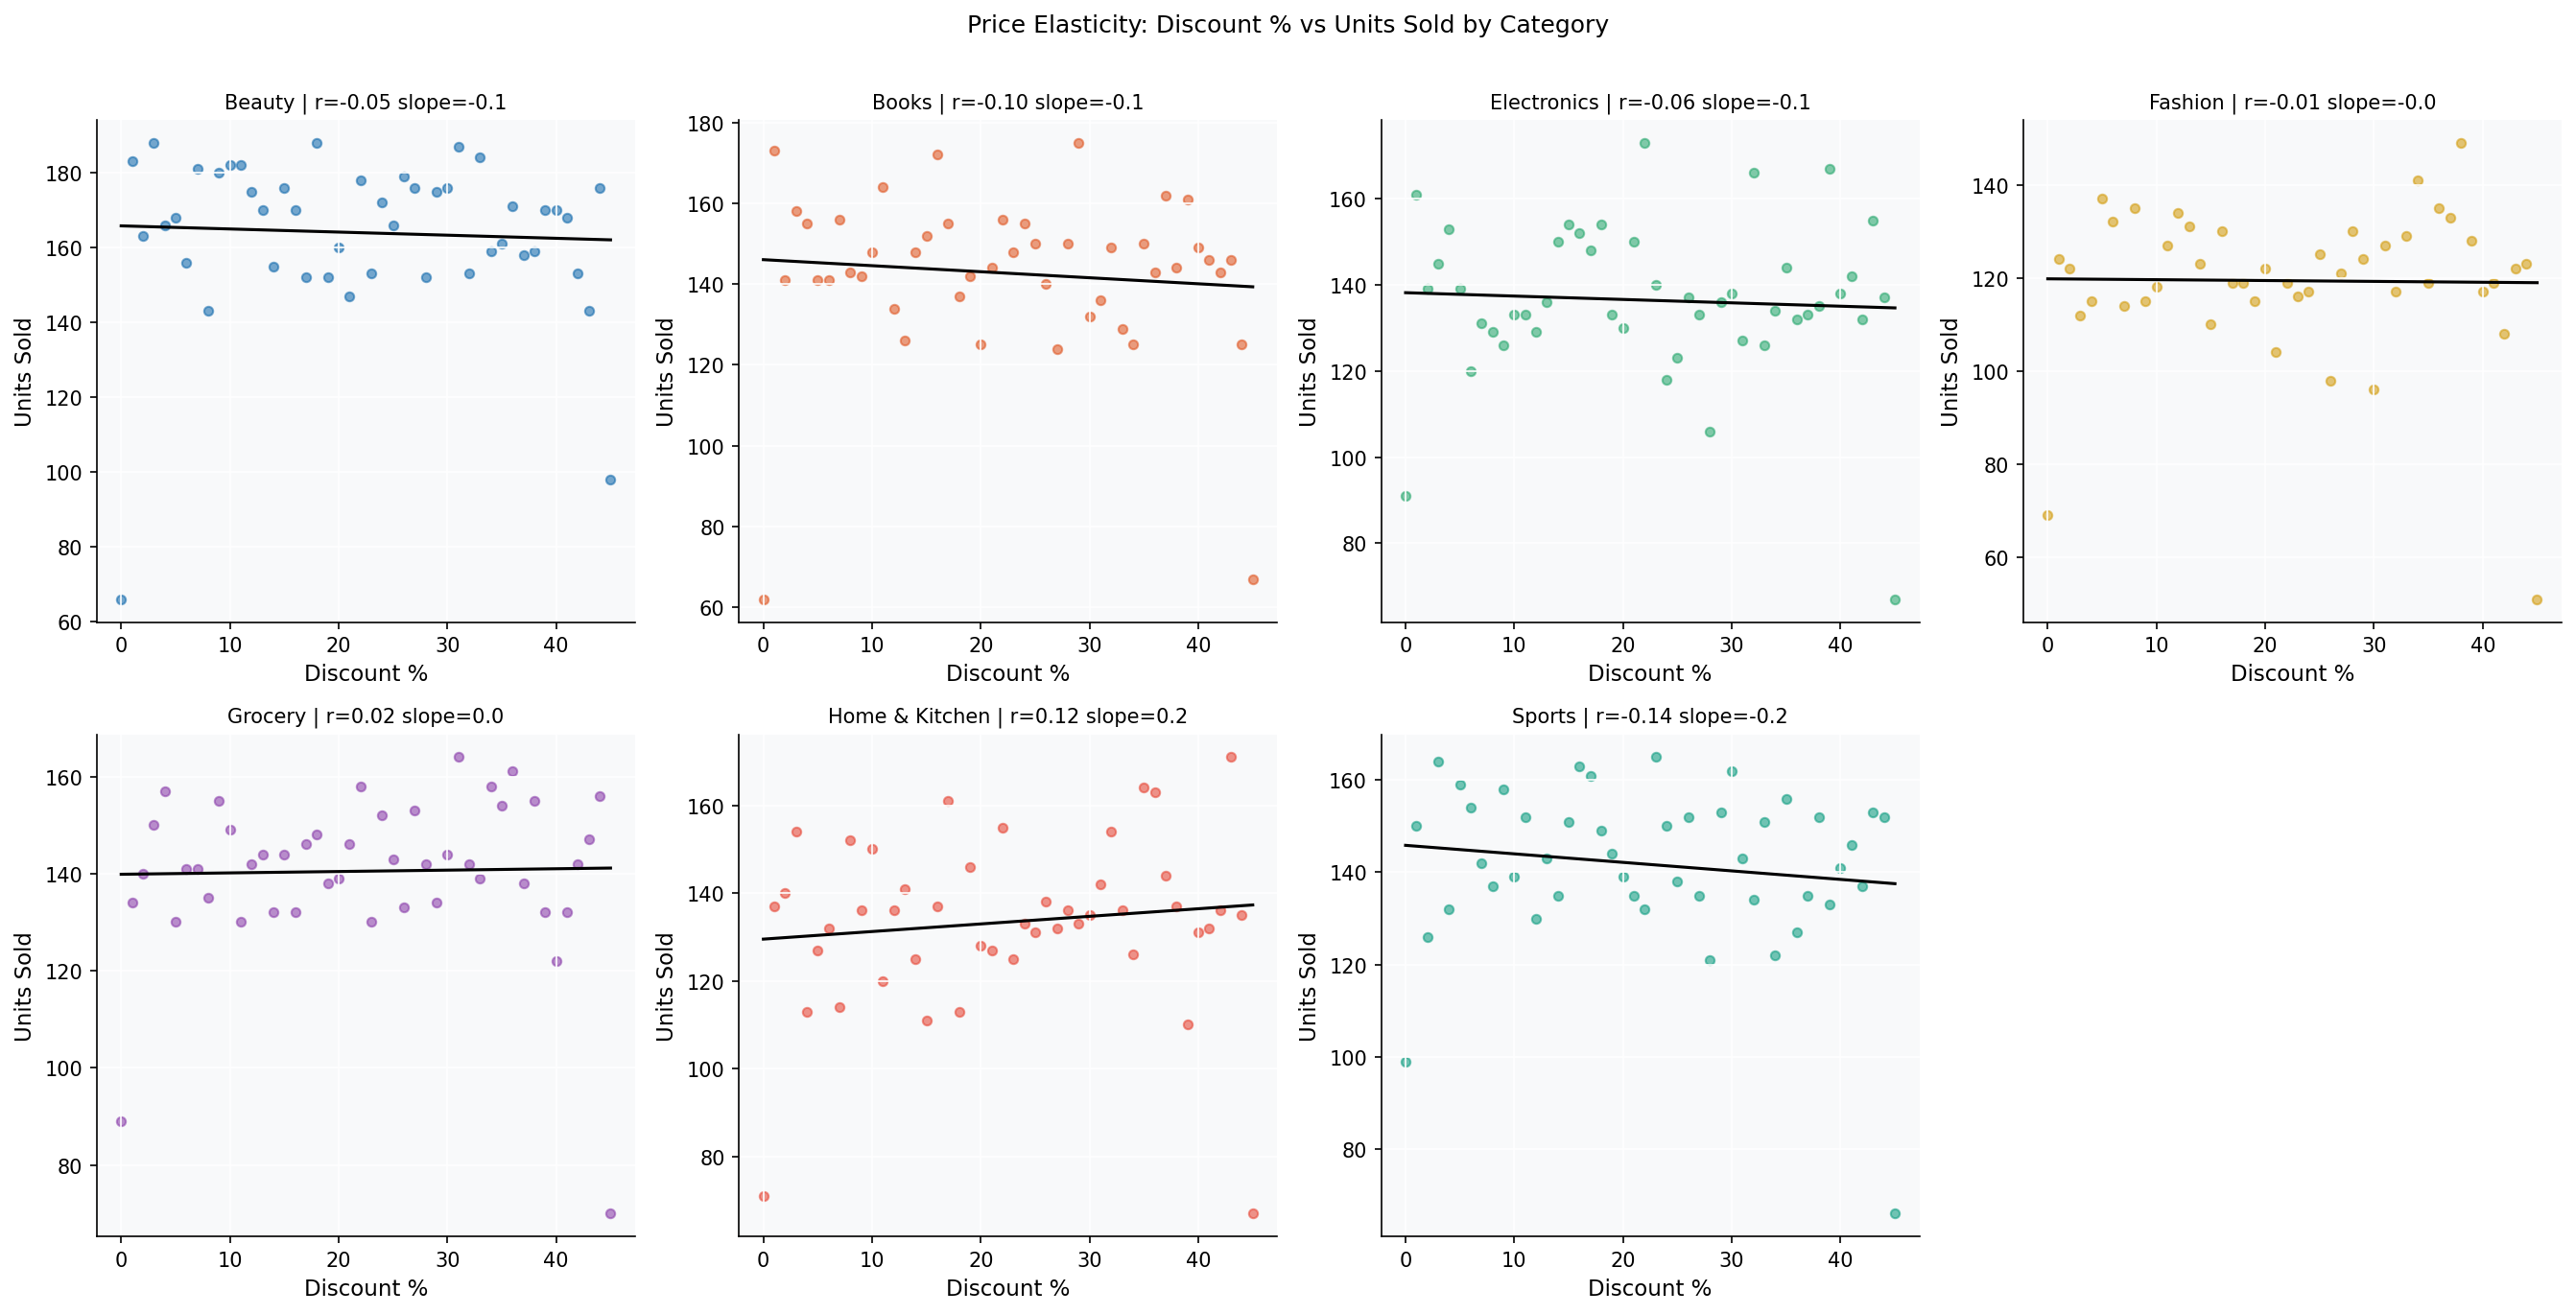

      category  slope  r_squared
Home & Kitchen   0.17      0.014
       Grocery   0.03      0.001
       Fashion  -0.02      0.000
        Beauty  -0.08      0.003
   Electronics  -0.08      0.003
         Books  -0.15      0.009
        Sports  -0.18      0.020


In [15]:
elast_data = (
    orders[orders['status'] != 'Cancelled']
    .merge(products[['product_id','category','mrp']], on='product_id')
    .assign(discount_pct=lambda d: (
        d['discount_amt'] / (d['gmv'] + d['discount_amt']) * 100).round(0))
)

categories = sorted(elast_data['category'].unique())
fig, axes  = plt.subplots(2, 4, figsize=(18, 9))
axes       = axes.flatten()
elasticity_results = []

for idx, cat in enumerate(categories):
    df_cat = (
        elast_data[elast_data['category'] == cat]
        .groupby('discount_pct')
        .agg(units_sold=('order_id','count'))
        .reset_index()
        .query('discount_pct >= 0 and discount_pct <= 60')
    )
    if len(df_cat) < 5:
        axes[idx].set_visible(False)
        continue

    slope, intercept, r, p, _ = stats.linregress(
        df_cat['discount_pct'], df_cat['units_sold'])
    ax = axes[idx]
    ax.scatter(df_cat['discount_pct'], df_cat['units_sold'],
               color=PALETTE[idx % len(PALETTE)], alpha=0.6, s=20)
    x_line = np.linspace(df_cat['discount_pct'].min(), df_cat['discount_pct'].max(), 100)
    ax.plot(x_line, slope*x_line+intercept, color='black', linewidth=1.5)
    ax.set_title(f'{cat} | r={r:.2f} slope={slope:.1f}', fontsize=10)
    ax.set_xlabel('Discount %')
    ax.set_ylabel('Units Sold')
    elasticity_results.append({'category':cat,'slope':round(slope,2),'r_squared':round(r**2,3)})

for i in range(len(categories), len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Price Elasticity: Discount % vs Units Sold by Category', y=1.01)
plt.tight_layout()
plt.savefig('../dashboard/screenshots/10_price_elasticity.png', bbox_inches='tight')
plt.show()

elast_df = pd.DataFrame(elasticity_results).sort_values('slope', ascending=False)
print(elast_df.to_string(index=False))

---
## Section 7 — Key Findings Summary

In [16]:
print("=" * 65)
print("  E-COMMERCE MARKETPLACE ANALYTICS - KEY FINDINGS")
print("=" * 65)

cat_gmv_share = (
    orders[orders['status'] != 'Cancelled']
    .merge(products[['product_id','category']], on='product_id')
    .groupby('category')['gmv'].sum().sort_values(ascending=False)
)
top2_share = cat_gmv_share.head(2).sum() / cat_gmv_share.sum() * 100
print(f"\n1. GMV CONCENTRATION")
print(f"   Top 2 categories drive {top2_share:.0f}% of total platform GMV.")

high_return = (
    orders[orders['status'] != 'Cancelled']
    .merge(products[['product_id','category']], on='product_id')
    .groupby('category')['return_flag'].mean()
    .mul(100).sort_values(ascending=False)
)
print(f"\n2. RETURN RATES")
print(f"   Highest return category : {high_return.index[0]} ({high_return.iloc[0]:.1f}%)")
print(f"   Lowest return category  : {high_return.index[-1]} ({high_return.iloc[-1]:.1f}%)")

churn_rate = cust_features['churned'].mean() * 100
print(f"\n3. CUSTOMER CHURN")
print(f"   90-day churn rate       : {churn_rate:.1f}%")
print(f"   Model ROC-AUC           : {roc_auc_score(y_test, y_prob):.3f}")

avg_disc = disc_monthly['discount_rate'].mean()
print(f"\n4. DISCOUNT BURN RATE")
print(f"   Avg monthly discount rate : {avg_disc:.1f}% of gross revenue")

fba_del = orders[orders['status']=='Delivered'].merge(
    sellers[['seller_id','fulfillment_type']], on='seller_id')
fba_avg  = fba_del[fba_del['fulfillment_type']=='FBA']['delivery_days'].mean()
self_avg = fba_del[fba_del['fulfillment_type']=='Self-Ship']['delivery_days'].mean()
print(f"\n5. FULFILLMENT SPEED")
print(f"   FBA avg delivery        : {fba_avg:.1f} days")
print(f"   Self-Ship avg delivery  : {self_avg:.1f} days")
print(f"   FBA advantage           : {abs(self_avg-fba_avg):.1f} days faster")

print("\n" + "=" * 65)
print("  All charts saved to dashboard/screenshots/")
print("=" * 65)

  E-COMMERCE MARKETPLACE ANALYTICS - KEY FINDINGS

1. GMV CONCENTRATION
   Top 2 categories drive 81% of total platform GMV.

2. RETURN RATES
   Highest return category : Electronics (9.2%)
   Lowest return category  : Home & Kitchen (8.6%)

3. CUSTOMER CHURN
   90-day churn rate       : 31.9%
   Model ROC-AUC           : 1.000

4. DISCOUNT BURN RATE
   Avg monthly discount rate : 22.6% of gross revenue

5. FULFILLMENT SPEED
   FBA avg delivery        : 7.6 days
   Self-Ship avg delivery  : 7.5 days
   FBA advantage           : 0.0 days faster

  All charts saved to dashboard/screenshots/


---
## Next Steps
- Open **Power BI Desktop** and follow `dashboard/power_bi_guide.md` to build the 4-page dashboard
- Push repo to `github.com/AyushDodia0125/Ecommerce-Marketplace-Analytics`
- Review `reports/insights_summary.pdf` for the executive findings report

---
*Ayush Dodia | ayushdodia2001@gmail.com*